In [40]:
import os

os.getcwd()

'/Users/shishir/Desktop/social-media-sentiment'

In [41]:
os.listdir()

['.DS_Store',
 'Untitled.ipynb',
 '.ipynb_checkpoints',
 'visuals',
 '.jupyter',
 'data',
 'notebooks']

In [42]:
import pandas as pd

df = pd.read_csv("data/tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [43]:
import os

os.listdir("data")

['.ipynb_checkpoints', 'tweets.csv']

In [44]:
import pandas as pd

df = pd.read_csv("data/tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [45]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

In [46]:
df = df[["text", "airline_sentiment"]]

df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [47]:
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

In [48]:
df = df.dropna(subset=["text"])

In [49]:
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

In [50]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [51]:
df["clean_text"] = df["text"].apply(clean_text)

In [52]:
df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


In [53]:
import nltk

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/shishir/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [54]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [55]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    
    if score >= 0.5:
        return "positive"
    elif score <= -0.5:
        return "negative"
    else:
        return "neutral"

In [56]:
df["sentiment"] = df["clean_text"].apply(get_sentiment)

In [57]:
df[["text", "sentiment"]].head(10)

,text,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,neutral
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,neutral
4,@VirginAmerica and it's a really big bad thing...,negative
5,@VirginAmerica seriously would pay $30 a fligh...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",neutral
7,@VirginAmerica Really missed a prime opportuni...,neutral
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",neutral
9,"@VirginAmerica it was amazing, and arrived an ...",positive


In [58]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts

sentiment
neutral     10060
positive     2604
negative     1976
Name: count, dtype: int64

In [59]:
sentiment_percentage = df["sentiment"].value_counts(normalize=True) * 100

sentiment_percentage

sentiment
neutral     68.715847
positive    17.786885
negative    13.497268
Name: proportion, dtype: float64

In [60]:
import matplotlib.pyplot as plt

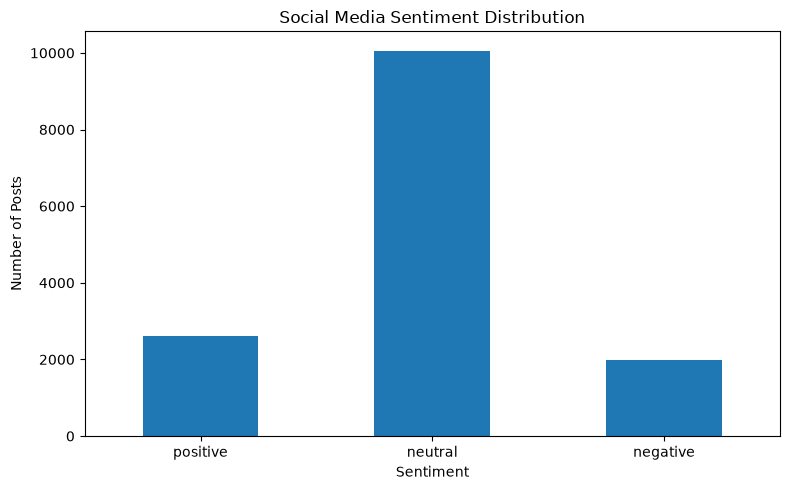

In [61]:
sentiment_counts = sentiment_counts.reindex(
    ["positive", "neutral", "negative"]
)

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Social Media Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visuals/sentiment_distribution.png", dpi=300)

plt.show()

In [62]:
from wordcloud import WordCloud


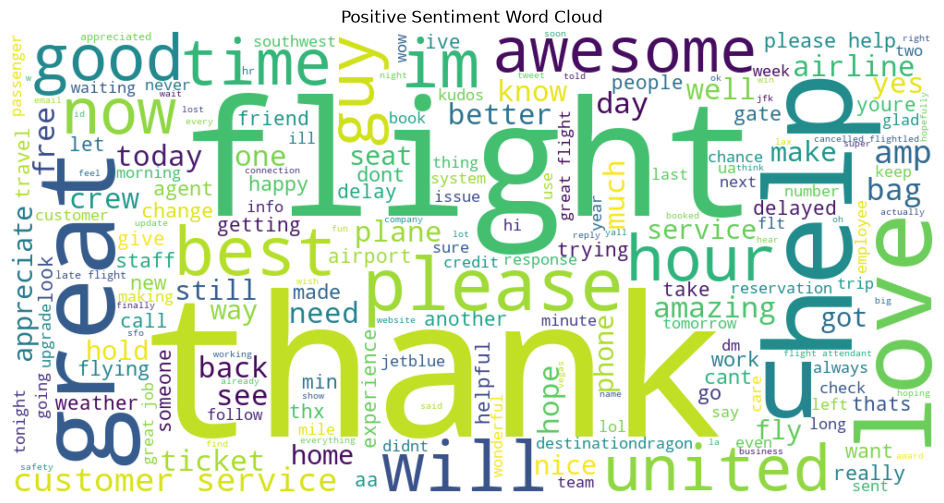

In [63]:
positive_text = " ".join(
    df[df["sentiment"] == "positive"]["clean_text"]
)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment Word Cloud")

plt.savefig("visuals/positive_wordcloud.png", dpi=300)

plt.show()

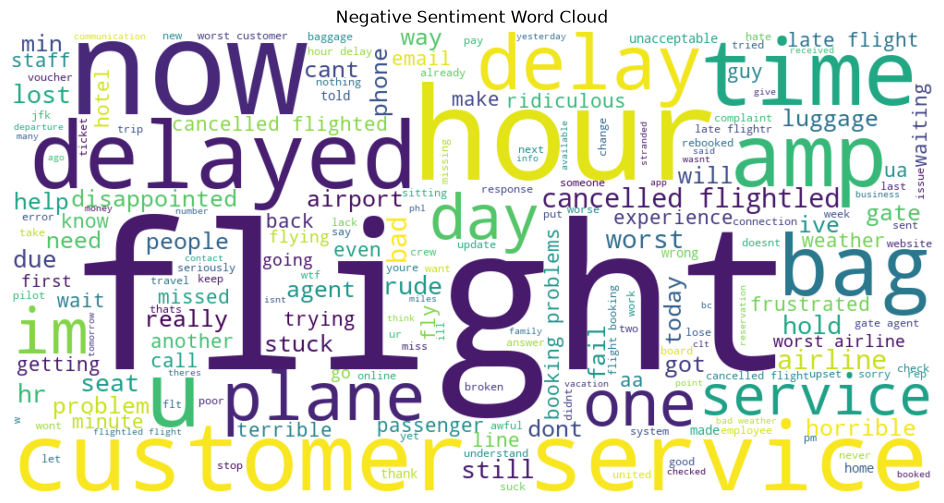

In [64]:
negative_text = " ".join(
    df[df["sentiment"] == "negative"]["clean_text"]
)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment Word Cloud")

plt.savefig("visuals/negative_wordcloud.png", dpi=300)

plt.show()

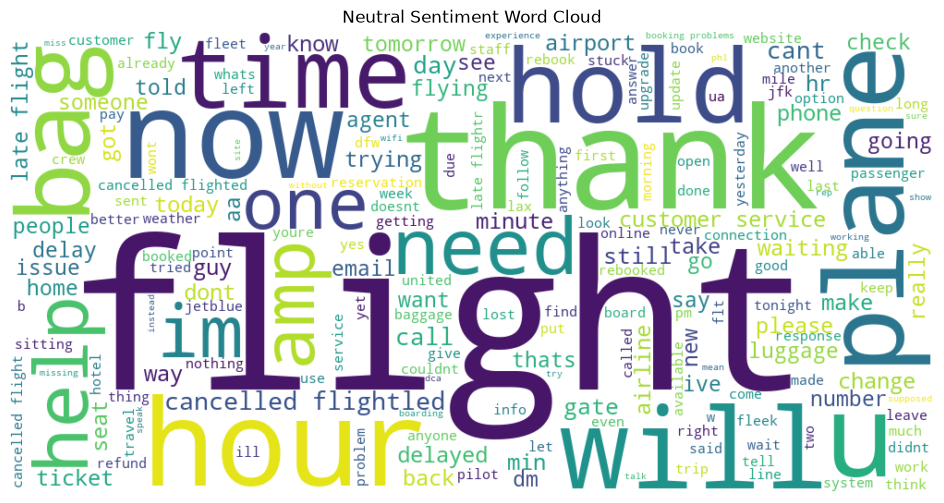

In [65]:
neutral_text = " ".join(
    df[df["sentiment"] == "neutral"]["clean_text"]
)

wordcloud_neutral = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment Word Cloud")

plt.savefig("visuals/neutral_wordcloud.png", dpi=300)

plt.show()

In [66]:
result_summary = pd.DataFrame({
    "Sentiment": sentiment_percentage.index,
    "Percentage": sentiment_percentage.values
})

result_summary

,Sentiment,Percentage
0,neutral,68.715847
1,positive,17.786885
2,negative,13.497268


In [67]:
from collections import Counter

def most_common_words(text, n=10):
    words = text.split()
    return Counter(words).most_common(n)

In [68]:
most_common_words(positive_text)

[('to', 1458),
 ('the', 1182),
 ('i', 961),
 ('you', 940),
 ('for', 849),
 ('a', 796),
 ('and', 648),
 ('on', 552),
 ('flight', 529),
 ('my', 522)]

In [69]:
most_common_words(negative_text)

[('to', 1203),
 ('the', 885),
 ('i', 705),
 ('and', 694),
 ('flight', 684),
 ('a', 667),
 ('is', 553),
 ('you', 542),
 ('no', 528),
 ('for', 510)]

In [70]:
most_common_words(neutral_text)

[('to', 5982),
 ('the', 3986),
 ('i', 3709),
 ('a', 3083),
 ('on', 2731),
 ('flight', 2682),
 ('for', 2636),
 ('you', 2628),
 ('and', 2367),
 ('my', 2243)]

In [72]:
most_common_words(neutral_text)


[('to', 5982),
 ('the', 3986),
 ('i', 3709),
 ('a', 3083),
 ('on', 2731),
 ('flight', 2682),
 ('for', 2636),
 ('you', 2628),
 ('and', 2367),
 ('my', 2243)]

In [73]:
%pip install pandas matplotlib nltk wordcloud

Note: you may need to restart the kernel to use updated packages.
